🎯 Improving Model Recall


Testing different prediction thresholds...
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

📊 Threshold Comparison:

Threshold 0.3:
  Precision: 0.711
  Recall:    0.246
  F1-Score:  0.366
  True Positives:  32
  False Positives: 13

Threshold 0.4:
  Precision: 0.800
  Recall:    0.246
  F1-Score:  0.376
  True Positives:  32
  False Positives: 8

Threshold 0.5:
  Precision: 0.833
  Recall:    0.231
  F1-Score:  0.361
  True Positives:  30
  False Positives: 6

Threshold 0.6:
  Precision: 0.909
  Recall:    0.231
  F1-Score:  0.368
  True Positives:  30
  False Positives: 3

Threshold 0.7:
  Precision: 0.909
  Recall:    0.231
  F1-Score:  0.368
  True Positives:  30
  False Positives: 3

🎉 Optimal Threshold: 0.4
   F1-Score: 0.376


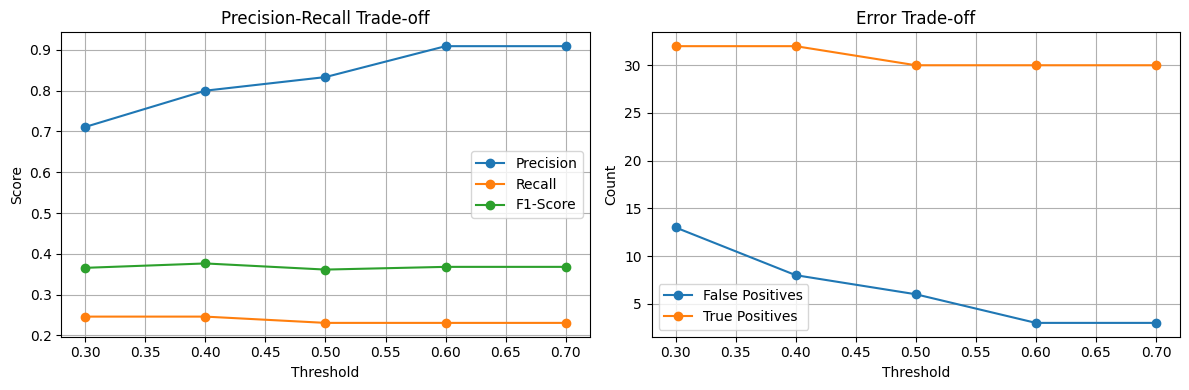


💾 Using threshold 0.4 for better performance

🎯 Final Performance with Optimal Threshold:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2552
           1       0.80      0.25      0.38       130

    accuracy                           0.96      2682
   macro avg       0.88      0.62      0.68      2682
weighted avg       0.96      0.96      0.95      2682

Confusion Matrix:
[[2544    8]
 [  98   32]]


In [1]:
# Improve Recall - Notebook 06
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🎯 Improving Model Recall")
print("=" * 50)

# Load model and data
model = load_model('../models/lstm_text_model.h5')
test_data = pd.read_csv('../data/processed/test_data.csv')

# Prepare features (same as before)
text_columns = ['description', 'requirements', 'company_profile']
test_data['combined_text'] = test_data[text_columns].fillna('').apply(lambda x: ' '.join(x), axis=1)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
train_data = pd.read_csv('../data/processed/train_data.csv')
train_data['combined_text'] = train_data[text_columns].fillna('').apply(lambda x: ' '.join(x), axis=1)
tokenizer.fit_on_texts(train_data['combined_text'])

X_test_text = tokenizer.texts_to_sequences(test_data['combined_text'])
X_test_text = pad_sequences(X_test_text, maxlen=200, padding='post', truncating='post')
X_test_numeric = test_data[['telecommuting', 'has_company_logo', 'has_questions']].values
y_test = test_data['fraudulent'].values

# Test different thresholds
print("Testing different prediction thresholds...")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = {}

y_pred_proba = model.predict([X_test_text, X_test_numeric]).flatten()

for threshold in thresholds:
    y_pred = (y_pred_proba > threshold).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[threshold] = {
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1_score': report['1']['f1-score'],
        'tp': confusion_matrix(y_test, y_pred)[1, 1],  # True positives
        'fp': confusion_matrix(y_test, y_pred)[0, 1]   # False positives
    }

# Display results
print("\n📊 Threshold Comparison:")
for threshold, metrics in results.items():
    print(f"\nThreshold {threshold}:")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall:    {metrics['recall']:.3f}")
    print(f"  F1-Score:  {metrics['f1_score']:.3f}")
    print(f"  True Positives:  {metrics['tp']}")
    print(f"  False Positives: {metrics['fp']}")

# Find optimal threshold (maximize F1-score)
best_threshold = max(results.items(), key=lambda x: x[1]['f1_score'])[0]
print(f"\n🎉 Optimal Threshold: {best_threshold}")
print(f"   F1-Score: {results[best_threshold]['f1_score']:.3f}")

# Visualize trade-off
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
thresholds_list = list(results.keys())
precisions = [results[t]['precision'] for t in thresholds_list]
recalls = [results[t]['recall'] for t in thresholds_list]
f1_scores = [results[t]['f1_score'] for t in thresholds_list]

plt.plot(thresholds_list, precisions, 'o-', label='Precision')
plt.plot(thresholds_list, recalls, 'o-', label='Recall')
plt.plot(thresholds_list, f1_scores, 'o-', label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
fp_counts = [results[t]['fp'] for t in thresholds_list]
tp_counts = [results[t]['tp'] for t in thresholds_list]

plt.plot(thresholds_list, fp_counts, 'o-', label='False Positives')
plt.plot(thresholds_list, tp_counts, 'o-', label='True Positives')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('Error Trade-off')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save optimal threshold
optimal_threshold = best_threshold
print(f"\n💾 Using threshold {optimal_threshold} for better performance")

# Final performance with optimal threshold
final_pred = (y_pred_proba > optimal_threshold).astype(int)
print("\n🎯 Final Performance with Optimal Threshold:")
print(classification_report(y_test, final_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))